# SciPy: Optimization

## 1. Mathematical foundations

### 1.1. Principles of convexity

#### Convex set
A set $\mathcal{S}$ is convex if the line between any two points $s_1,s_2\in\mathcal{S}$ lies completely inside $\mathcal{S}$. Formally:

$$\lambda s_1+(1-\lambda)s_2\in \mathcal{S}\qquad\forall\;\lambda\in[0,1]$$

:::{image} ../image/chap_02/convex_set.svg
:height: 250px
:align: center
:::

#### Convex function
A function $f(x)$ is convex if (1) its domain is convex and (2) the curve between any two points $x_1,x_2\in\text{dom}(f)$ lies under the segment between them:

$$f(\lambda x_1+(1-\lambda)x_2)\leq\lambda f(x_1)+(1-\lambda)f(x_2)\qquad\forall\;\lambda\in[0,1]$$

Equivalently, $f(x)$ is also convex if it satisfies one of these (differentiability assumed):
- First-order condition: The tangent line at any point lies below the graph of the function: 

$$f(x_2)\geq f(x_1)+\nabla f(x_1)^\top(x_2-x_1)$$

- Second-order condition: The function is curved upward in all directions (think of a bowl):

$$\nabla^2f(x)\succeq0$$

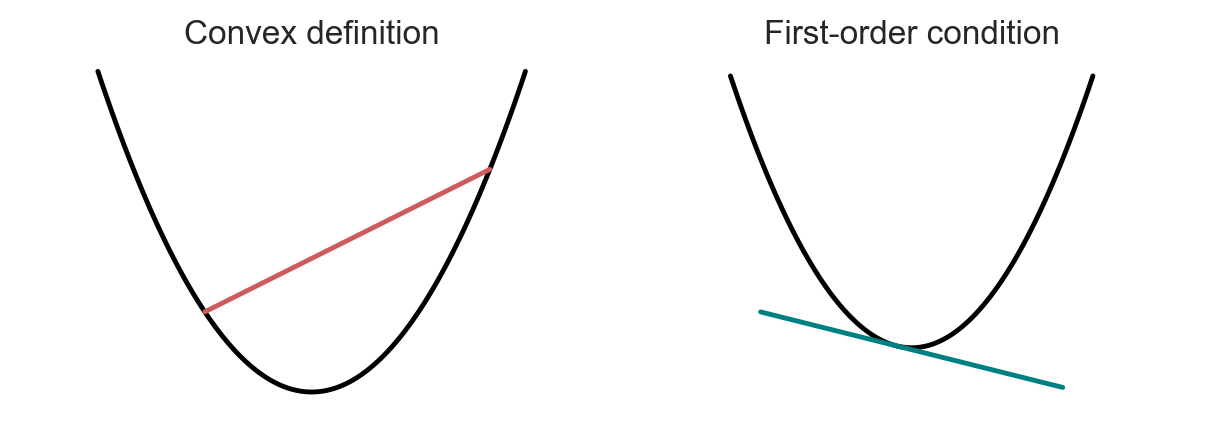

In [34]:
import sys; sys.path.append('..')
from mlkit import np, plt, sns

def f(x):
    return x ** 2 / 2

x_graph = np.linspace(-3, 3, 100)
y_graph = f(x_graph)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(6,2))
ax[0].plot(x_graph, y_graph, 'k')
ax[0].axis('equal')
ax[0].grid(False)
ax[0].set_axis_off()
ax[0].set_title('Convex definition')

x_dom = np.array([-1.5, 2.5])
y_dom = f(x_dom)
ax[0].plot(x_dom, y_dom, 'indianred')

ax[1].plot(x_graph, y_graph, 'k')
ax[1].axis('equal')
ax[1].grid(False)
ax[1].set_axis_off()
ax[1].set_title('First-order condition')

def tangent_line(x):
    return -0.25*x - 0.03125

x_tng = np.array([-2.5, 2.5])
y_tng = tangent_line(x_tng)
ax[1].plot(x_tng, y_tng, 'teal')

plt.show()

:::{note}
- Any local minimum of a convex function $f$ is also its global minimum.
- If $f$ is convex then $-f$ is concave, whose domain is still a convex set.
- There is no such thing as "a concave set".
:::

### 1.2. Derivative tests
[Derivative tests] use $f'(x)$ and $f''(x)$ to read a function's shape. The first derivative controls [monotonicity] and flags [stationary points]; the second derivative controls [curvature] and helps locate [inflection points].

[Derivative tests]: https://en.wikipedia.org/wiki/Derivative_test
[monotonicity]: https://en.wikipedia.org/wiki/Monotonic_function
[stationary points]: https://en.wikipedia.org/wiki/Stationary_point
[curvature]: https://en.wikipedia.org/wiki/Concave_function
[inflection points]: https://en.wikipedia.org/wiki/Inflection_point

In [1]:
import sys; sys.path.append('..')
from mlkit import np, sym, plt

In [2]:
bound_left, bound_right = -2.2, 2.6

map_sign_color = {
    'negative': 'indianred',
    'positive': 'royalblue',
    '-': 'indianred',
    '+': 'royalblue',
}

def phi(x):
    return (2*x**5 - x**4 - 10*x**3) / 16

x = sym.Symbol('x')
y = phi(x)

derivative_1st = sym.lambdify(x, y.diff(), 'numpy')

y

x**5/8 - x**4/16 - 5*x**3/8

#### First derivative
The first derivative represents the function's *instantaneous velocity*. So if we know the sign of $f'(x)$ on each interval, we immediately know where $f(x)$ is increasing or decreasing. Here are quick rules for geometric meaning:
- $f'(x)>0$: graph rises as $x$ increases (increasing).
- $f'(x)<0$: graph falls as $x$ increases (decreasing).
- Larger $|f'(x)|$ means steeper graph (changes faster). Smaller $|f'(x)|$ means flatter graph (changes slowler).
- $f'(x)=0$: a stationary point (flat tangent). It *may* be a local [extremum] but it need further checks (sign change or second derivative test) to classify it.
- In higher dimensions, a zero gradient $\nabla f(\mathbf{x}) = \mathbf{0}$ indicates a flat tangent plane. While this can be a peak or valley, it often represents a [saddle point], where the function increases in one direction but decreases in another.

[extremum]: https://en.wikipedia.org/wiki/Maximum_and_minimum
[saddle point]: https://en.wikipedia.org/wiki/Saddle_point

::::{admonition} Practice
:class: tip

Let's take a look at the function:

$$y=\phi(x)=\frac{2x^5-x^4-10x^3}{16}$$

First, we build the sign table for $\phi'(x)$ and what it implies for $\phi(x)$:

|$x$    |$-\infty$|   |$-1.544$|   |$0$|   |$1.944$|   |$\infty$|
|:-----:|:-------:|:-:|:------:|:-:|:-:|:-:|:-----:|:-:|:------:|
|$f'(x)$|         |$+$|$0$     |$-$|$0$|$-$|$0$    |$+$|        |

<br>

Next, we plot $\phi(x)$ where red intervals indicate $\phi'(x)<0$ and blue intervals indicate $\phi'(x)>0$.

:::{image} ../export/chap_02/function_monotonicity.svg
:height: 300px
:align: center
:::
<br>

The black dots mark where $\phi'(x)=0$; these are stationary points. But not all of them behave the same:
- At $x \approx -1.544$, $\phi'(x)$ changes from positive to negative, so the function switches from increasing to decreasing. We conclude this is a local maximum.
- At $x \approx 1.944$, $\phi'(x)$ changes from negative to positive, so the function switches from decreasing to increasing. We conclude this is a local minimum.
- At $x=0$, the sign of $\phi'(x)$ stays negative on both sides, so the function keeps decreasing through the point. This is not a max or a min.

::::

In [ ]:
list_stationary = [float(i) for i in sorted(sym.solveset(y.diff(), x))]
list_interval = [
    np.linspace(bound_left, list_stationary[0], 1000),
    np.linspace(list_stationary[0], list_stationary[1], 1000),
    np.linspace(list_stationary[1], list_stationary[2], 1000),
    np.linspace(list_stationary[2], bound_right, 1000),
]

fig, ax = plt.subplots()
ax.axhline(0, c='grey')

ax.plot(list_interval[0], phi(list_interval[0]), color=map_sign_color['+'], label='Increasing (velocity > 0)')
ax.plot(list_interval[1], phi(list_interval[1]), color=map_sign_color['-'], label='Decreasing (velocity < 0)')
ax.plot(list_interval[2], phi(list_interval[2]), color=map_sign_color['-'])
ax.plot(list_interval[3], phi(list_interval[3]), color=map_sign_color['+'])

for stationary in list_stationary:
    ax.plot(stationary, phi(stationary), 'ok')
    ax.axvline(stationary, ls='--', c='grey', alpha=0.5)

ax.legend()
ax.axis('scaled')
ax.grid(False)
ax.set_xticks(list_stationary)
ax.set_yticks([])

fig.savefig('../export/chap_02/function_monotonicity.svg', dpi=500, bbox_inches='tight')
plt.close(fig)

#### Second derivative
The [second derivative] represents the function's *instantaneous acceleration*.
- $f''(x)>0$: increasing velocity, the graph bends upward (convex).
- $f''(x)<0$: decreasing velocity, the graph bends downward (concave).
- Large $|f''(x)|$ means the graph has a sharp, tight turn. Small $|f''(x)|$ means the graph has a gentle, gradual curve.
- In higher dimensions, positive definite Hessian matrix $\nabla^2f(\mathbf{x})$ indicates a convex function.

[second derivative]: https://en.wikipedia.org/wiki/Second_derivative

::::{admonition} Practice
:class: tip

Let's do the second-derivative test for $\phi(x)$. Here is how the table of sign of $\phi''(x)$ looks like:

|$x$     |$-\infty$|   |$-1.084$|   |$0$|   |$1.384$|   |$\infty$|
|:------:|:-------:|:-:|:------:|:-:|:-:|:-:|:-----:|:-:|:------:|
|$f''(x)$|         |$-$|$0$     |$+$|$0$|$-$|$0$    |$+$|        |

<br>

Next, we plot both $\phi(x)$ and $\phi'(x)$. Black dots are where $\phi''(x)=0$; they split the function into convex (blue) and concave (red) intervals clearly.

:::{image} ../export/chap_02/function_curvature.svg
:height: 300px
:align: center
:::

::::

In [18]:
list_inflection = [float(i) for i in sorted(sym.solveset(y.diff().diff(), x))]

list_interval = [
    np.linspace(bound_left, list_inflection[0], 1000),
    np.linspace(list_inflection[0], list_inflection[1], 1000),
    np.linspace(list_inflection[1], list_inflection[2], 1000),
    np.linspace(list_inflection[2], bound_right, 1000),
]

x_plot = np.linspace(bound_left+0.5, bound_right-0.5, 1000)

fig, ax = plt.subplots()
ax.axhline(0, c='grey')

ax.plot(x_plot, derivative_1st(x_plot), c='grey', label='Velocity')

ax.plot(list_interval[0], phi(list_interval[0]), color=map_sign_color['-'], label='Concave (acceleration < 0)')
ax.plot(list_interval[1], phi(list_interval[1]), color=map_sign_color['+'], label='Convex (acceleration > 0)')
ax.plot(list_interval[2], phi(list_interval[2]), color=map_sign_color['-'])
ax.plot(list_interval[3], phi(list_interval[3]), color=map_sign_color['+'])

for inflection in list_inflection:
    ax.plot(inflection, phi(inflection), 'ok')
    ax.plot(inflection, derivative_1st(inflection), 'ok')
    ax.axvline(inflection, ls='--', c='grey', alpha=0.5)

ax.legend()
ax.axis('scaled')
ax.grid(False)
ax.set_xticks(list_inflection)
ax.set_yticks([])

ax.text(
    x_plot[-1] - 0.1, derivative_1st(x_plot[-1]) - 0.1, 'Derivative', 
    fontsize=12, va='center', ha='right'
)

ax.text(
    list_interval[-1][-1] - 0.1, phi(list_interval[-1][-1]) + 0.1, 'Function', 
    fontsize=12, va='bottom', ha='center'
)

fig.savefig('../export/chap_02/function_curvature.svg', dpi=500, bbox_inches='tight')
plt.close(fig)

:::{note}
Combining both first and second derivative tests gives local extrema:
- If $f'(a)=0$ and $f''(a)>0$ then $x=a$ is a local minimum of $f(x)$
- If $f'(a)=0$ and $f''(a)<0$ then $x=a$ is a local maximum of $f(x)$
:::

### 1.3. Matrix definiteness
[Matrix definiteness] is the matrix version of "a scalar being positive or negative". It shows up everywhere in optimization because Hessians are (usually) symmetric, and their definiteness tells you about curvature (convex/concave).

[Matrix definiteness]: https://en.wikipedia.org/wiki/Definite_matrix

#### Definition and intuition
Positive definite is a direct generalization of "positive":
- A scalar is positive ($a>0$) if multiplying by $a$ preserves the sign of any number $x\neq0$: Formally: $x(ax)>0$.
- A matrix is positive definite ($\mathbf{A}\succ0$) if the transformation $\mathbf{A}$ never flips any vector $\mathbf{x}\neq\mathbf{0}$ into a negative direction. Formally: $\mathbf{x}^\top (\mathbf{Ax}) > 0$.

:::{note}
In practice, definiteness is usually discussed for square, symmetric matrices, which is exactly the case for Hessians in most optimization problems.
:::

#### Types and notation
Let $\mathbf{A} \in \mathbb{R}^{N\times N}$ be symmetric.

|Type of definiteness|Notation|Scalar version|Definition|
|:-|:-:|:-:|:-|
|Positive definite| $\mathbf{A}\succ0$ | $a>0$ | $\mathbf{x}^\top\mathbf{Ax}>0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Negative definite| $\mathbf{A}\prec0$ | $a<0$ | $\mathbf{x}^\top\mathbf{Ax}<0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Positive semi-definite| $\mathbf{A}\succeq0$ | $a\geq0$| $\mathbf{x}^\top\mathbf{Ax}\geq0\;\forall\;\mathbf{x}$ |
|Negative semi-definite| $\mathbf{A}\preceq0$ | $a\leq0$| $\mathbf{x}^\top\mathbf{Ax}\leq0\;\forall\;\mathbf{x}$ |
|Non-definite||| $\exists\;\mathbf{x}:\mathbf{x}^\top\mathbf{Ax}>0;\;\exists\;\mathbf{y}:\mathbf{y}^\top\mathbf{Ay}>0$ |
|Shifted positive definite| $\mathbf{A}\succ\mu$ | $a>\mu$ | $\mathbf{A}-\mu\mathbf{I}\succ0$

### Definiteness tests
You can check definiteness in a few standard ways (again, assume $\mathbf{A} \in \mathbb{R}^{N\times N}$ is symmetric).
- Quadratic test (definition): look at $\mathbf{x}^\top\mathbf{Ax}$ and use the definitions. This is the most direct test, but not always the easiest to compute.
- Spectral test: check eigenvalues $\lambda_n$.
    - If all are positive or negative then $\mathbf{A}$ is definite
    - If all are $\geq0$ or $\leq0$ then $\mathbf{A}$ is semi-definite
    - If some are positive and some are negative then $\mathbf{A}$ is non-definite
- Sylvester test: check determinants of all leading principal minors $\det(\mathbf{A}_{1:n,1:n})$.
    - If all are positive then $\mathbf{A}$ is positive definite
    - If they have alternating signs, starting from positive, then $\mathbf{A}$ is nagative definite.

## 2. Unconstrained optimization
In unconstrained optimization, we want to find an $\mathbf{x}\in\mathbb{R}^N$ that minimizes a scalar objective $f:\mathbb{R}^N\mapsto\mathbb{R}$:

$$\mathbf{x}^\star=\arg\min f(\mathbf{x})$$

In practice, most algorithms are *local* methods: they aim for a point where $\nabla f(\mathbf{x}^\star)=\mathbf{0}$, which is a neccessary condition for a local minimum.

### 2.1. Theoretical frameworks
To optimize a function iteratively, we move from a starting point $\mathbf{x}_0$ through a series of steps to reach a local minimum. The two most prominent strategies for deciding how to take these steps are [line search] (direction first, then step size) and [trust region] (region first, then step) methods.

[line search]: https://en.wikipedia.org/wiki/Line_search
[trust region]: https://en.wikipedia.org/wiki/Trust_region

#### Line search
In practice, line search is the standard workhorse for most Data Science and Deep Learning applications. This approach find the search direction $\mathbf{p}_k$ and step size $\alpha_k$ at iteration $k$:

$$\mathbf{x}_{k+1}=\mathbf{x}_k+\alpha_k\mathbf{p}_k$$

A local surrogate $\sigma_k(\mathbf{x})$ will be constructed at each step that approximates $f(\mathbf{x})$ near the current point $\mathbf{x}_k$. $\sigma$ is taken to be the Taylor expansion of the objective, usually truncated at first order ([Gradient Descent]) or at second order ([Newton-Raphson]).

Next position will be evaluated by minimizing this surrogate: $\mathbf{x}_{k+1}=\arg\min \sigma_k(\mathbf{x})$. This gives us $\mathbf{p}_k$ a descent direction: $\mathbf{p}_k^\top\nabla f(\mathbf{x}_k)<0$ and has two forms:
- Gradient Descent: $\mathbf{p}_k=-\mathbf{g}_k$
- Newton-Raphson: $\mathbf{p}_k=-\mathbf{H}_k^{-1}\mathbf{g}_k$


[Gradient Descent]: https://en.wikipedia.org/wiki/Gradient_descent
[Newton-Raphson]: https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization

#### Newton-Raphson
This method uses the second Taylor expansion as the surrogate:

$$
\sigma_k(\mathbf{x})
= f(\mathbf{x}_k)
+ \mathbf{g}_k^\top(\mathbf{x}
- \mathbf{x}_k)
+ \dfrac{1}{2}(\mathbf{x} - \mathbf{x}_k)^\top \mathbf{H}_k(\mathbf{x}-\mathbf{x}_k)
$$

Here, $\mathbf{g}_k=\nabla f(\mathbf{x}_k)$ and $\mathbf{H}_k=\nabla^2 f(\mathbf{x}_k)$ are the gradient and Hessian evaluated at $\mathbf{x}_k$. Solving for $\mathbf{x}_{k+1}=\arg\min \sigma_k(\mathbf{x})$, we have the update direction $\mathbf{p}_k=-\mathbf{H}_k^{-1}\mathbf{g}_k$

:::{note}
Newton-Raphson is originally a [root finding] method, which solves for $f(\mathbf{x})=0$ and the update formula is:

$$\mathbf{x}_{k+1}=\mathbf{x}_k-\nabla f(\mathbf{x}_k)^\top f(\mathbf{x}_k)$$

If we solve for $\nabla f(\mathbf{x})=\mathbf{0}$, we get the same update formula in optimization.
:::

[root finding]: https://en.wikipedia.org/wiki/Newton%27s_method

### 2.2. Practical algorithms

## 3. Constrained optimization

### 3.1. Lagrange multipliers

### 3.2. KKT conditions

### 3.3. Duality in Machine Learning

## 4. Optimization in practice

### 4.1. Problem classification

### 4.2. Implementation: SciPy

### 4.3. Implementation: OR-Tools

## Resources
- gregorygundersen.com - [Understanding Positive Definite Matrices](https://gregorygundersen.com/blog/2022/02/27/positive-definite/)